In [1]:
import matplotlib.pyplot as plt
import imageio
import numpy as np

import sys
sys.path.append('./src')
import warnings
warnings.filterwarnings("ignore")

from data import PPCI

In [3]:
dataset = PPCI(encoder = "dino",
               token = "all",
               task = "or",
               split_criteria = "experiment_easy",
               environment = "supervised",
               batch_size = 256,
               num_proc = 4,
               verbose = True,
               data_dir = 'data/istant_hq',
               results_dir = 'results/istant_hq')
dataset.train(add_pred_env="supervised", 
              hidden_layers = 1,
              hidden_nodes = 256,
              batch_size = 256,
              lr = 0.005,
              seed = 1,
              num_epochs=10,
              save = False,
              verbose=True,
              force=True)

Embeddings from encoder 'dino' token 'class' already extracted for the supervised environment.
Embeddings from encoder 'dino' token 'mean' already extracted for the supervised environment.
Prediction-Powered Causal Inference dataset successfully loaded.
Device: cpu
Starting perfomances
  train:  Accuracy=0.778, Precision=nan, Recall=0.000
  val:  Accuracy=0.773, Precision=nan, Recall=0.000
Epoch 1
  Train: Loss=0.976
  train:  Accuracy=0.939, Precision=0.823, Recall=0.926
  val:  Accuracy=0.869, Precision=0.692, Recall=0.768
Epoch 2
  Train: Loss=0.276
  train:  Accuracy=0.927, Precision=0.761, Recall=0.979
  val:  Accuracy=0.852, Precision=0.621, Recall=0.897
Epoch 3
  Train: Loss=0.233
  train:  Accuracy=0.954, Precision=0.900, Recall=0.893
  val:  Accuracy=0.884, Precision=0.756, Recall=0.727
Epoch 4
  Train: Loss=0.217
  train:  Accuracy=0.961, Precision=0.910, Recall=0.917
  val:  Accuracy=0.873, Precision=0.703, Recall=0.769
Epoch 5
  Train: Loss=0.186
  train:  Accuracy=0.963, P

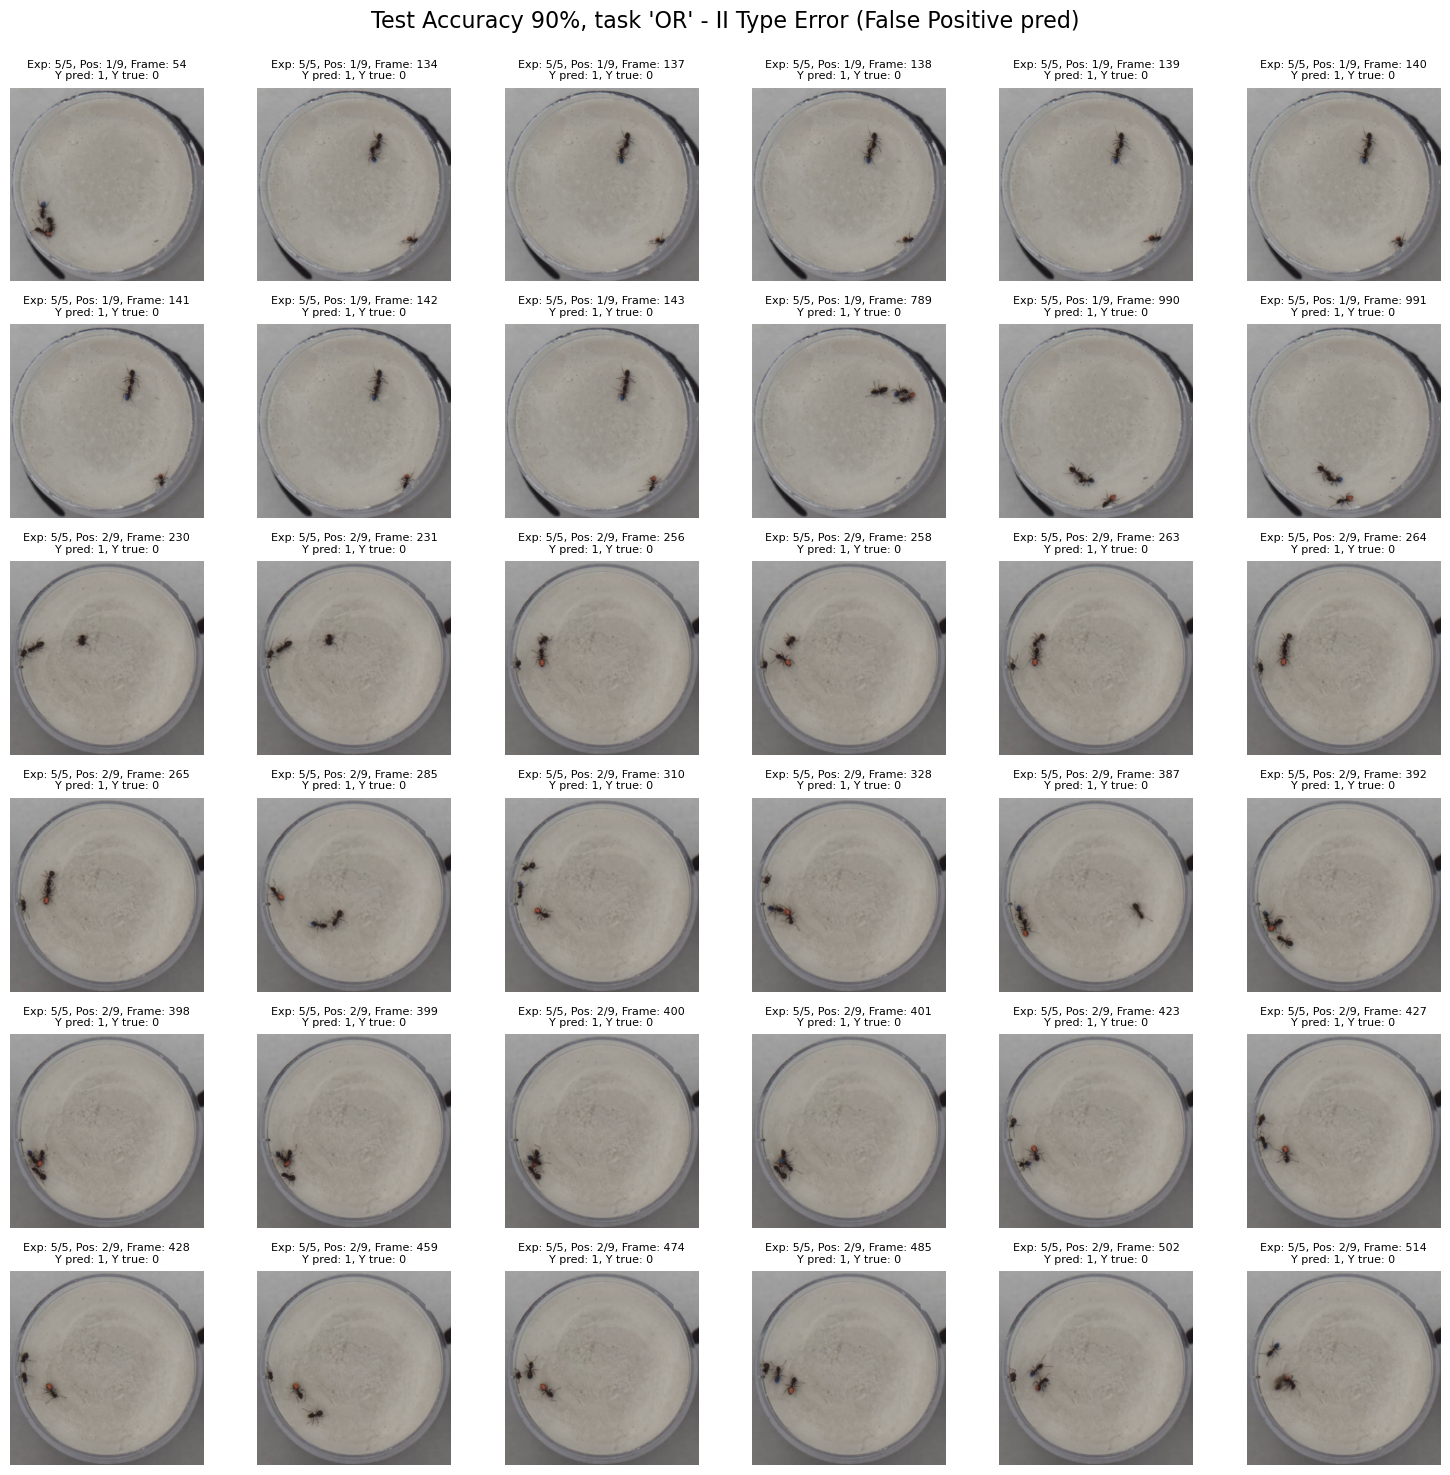

In [62]:
Y_hats = dataset.supervised["Y_hat"].round()
Ys = dataset.supervised["Y"]
split = dataset.supervised["split"]

idxs = ((Y_hats > Ys) & np.logical_not(split)).nonzero(as_tuple=True)[0]
N = 36
fig, axs = plt.subplots(6, 6, figsize=(15, 15))
fig.suptitle(f"Test Accuracy 90%, task 'OR' - II Type Error (False Positive pred)\n", fontsize=16)
for i, idx in enumerate(idxs[:N]):
    obs = dataset.supervised["source_data"][idx.item()]
    exp = obs["experiment"]
    pos = obs["position"]
    T = obs["treatment"]
    min = obs["exp_minute"]
    frame = obs["frame"]
    hour = obs["day_hour"]
    img = obs["image"]
    Y = int(Ys[idx].item())
    Y_hat = int(Y_hats[idx].item())
    axs[i//6, i%6].imshow(img.permute(1, 2, 0))
    axs[i//6, i%6].set_title(f"Exp: {exp+1}/5, Pos: {pos}/9, Frame: {frame}\nY pred: {Y_hat}, Y true: {Y}", fontsize=8)
    axs[i//6, i%6].axis('off')
plt.tight_layout()
plt.savefig("results/istant_hq/TestFP.png")